In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt

# Device configuration: NVIDIA GPU (Kaggle/Colab) -> Apple Silicon GPU -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Mixed precision only helps on CUDA; MPS and CPU train in float32
use_amp = device.type == 'cuda'
print(f"Accelerating on: {device} (AMP: {use_amp})")

Accelerating on: mps (AMP: False)


In [2]:
# RAF-DB colour dataset laid out as <data_dir>/train/1..7 and <data_dir>/test/1..7
# Uses the Kaggle input when running on Kaggle, otherwise the local copy in ../data/raf-db
kaggle_dir = '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET'
data_dir = kaggle_dir if os.path.isdir(kaggle_dir) else '../data/raf-db'

# Notice: Grayscale is REMOVED because RAF-DB provides high-quality RGB images
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(f'{data_dir}/{x}', data_transforms[x]) for x in ['train', 'test']}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=(x == 'train'), num_workers=2,
                  pin_memory=use_amp, persistent_workers=True)
    for x in ['train', 'test']
}

class_names = image_datasets['train'].classes
# RAF-DB label meanings for folders '1'..'7' (same order as the video inference scripts)
emotion_names = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Anger', 'Neutral']
print(f"Detected Classes: {class_names}")
print(f"Train images: {len(image_datasets['train'])}, Test images: {len(image_datasets['test'])}")

Detected Classes: ['1', '2', '3', '4', '5', '6', '7']
Train images: 12271, Test images: 3068


In [3]:
# Fixed the deprecation warning by using the 'weights' parameter
model = models.resnet18(weights='IMAGENET1K_V1')

# Add Dropout before the final classification layer to prevent overfitting
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, len(class_names)) 
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/user45/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  0%|          | 128k/44.7M [00:00<03:45, 207kB/s]

  1%|          | 256k/44.7M [00:00<02:18, 337kB/s]

  1%|          | 384k/44.7M [00:01<02:03, 377kB/s]

...

 99%|█████████▉| 44.2M/44.7M [01:27<00:00, 627kB/s]

 99%|█████████▉| 44.4M/44.7M [01:27<00:00, 586kB/s]

100%|█████████▉| 44.5M/44.7M [01:27<00:00, 583kB/s]

100%|█████████▉| 44.6M/44.7M [01:27<00:00, 681kB/s]

100%|██████████| 44.7M/44.7M [01:28<00:00, 532kB/s]

In [4]:
epochs = 12
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Label smoothing handles noisy labels in datasets

# Upgraded from SGD to AdamW for faster and more stable convergence
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, 
    steps_per_epoch=len(dataloaders['train']), 
    epochs=epochs
)

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    # With enabled=False (MPS/CPU) the scaler and autocast are no-ops
    scaler = GradScaler(device.type, enabled=use_amp)
    total_steps_limit = num_epochs * len(dataloaders['train'])
    current_step = 0

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        epoch_start = time.time()
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(device.type, enabled=use_amp):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()

                        before_step_scale = scaler.get_scale()
                        scaler.step(optimizer)
                        scaler.update()

                        if current_step < total_steps_limit:
                            if scaler.get_scale() >= before_step_scale:
                                scheduler.step()
                                current_step += 1

                running_loss += loss.item() * inputs.size(0)
                # Count as a Python int: MPS does not support float64 tensors
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects / len(image_datasets[phase])

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Epoch time: {time.time() - epoch_start:.0f}s')

    return model, history

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=epochs)

Epoch 1/12


train Loss: 1.4858 Acc: 0.5097


test Loss: 1.0319 Acc: 0.7324
Epoch time: 103s
Epoch 2/12


train Loss: 1.0423 Acc: 0.7300


test Loss: 1.0511 Acc: 0.7200
Epoch time: 118s
Epoch 3/12


...

test Loss: 0.7629 Acc: 0.8615
Epoch time: 226s
Epoch 11/12


train Loss: 0.5383 Acc: 0.9756


test Loss: 0.7553 Acc: 0.8667
Epoch time: 258s
Epoch 12/12


train Loss: 0.5231 Acc: 0.9821


test Loss: 0.7540 Acc: 0.8690
Epoch time: 280s


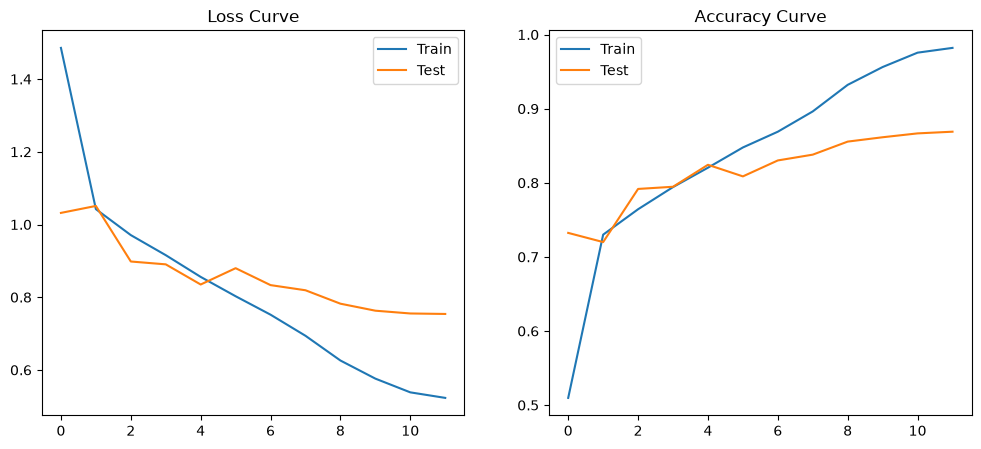

✅ RAF-DB Model saved successfully to 'resnet18_rafdb_final.pth'


In [6]:
# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['test_loss'], label='Test')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['test_acc'], label='Test')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# Save the RAF-DB trained model
torch.save(model.state_dict(), 'resnet18_rafdb_final.pth')
print("✅ RAF-DB Model saved successfully to 'resnet18_rafdb_final.pth'")

In [7]:
# Per-class accuracy on the RAF-DB test set
model.eval()
correct = torch.zeros(len(class_names), dtype=torch.long)
total = torch.zeros(len(class_names), dtype=torch.long)

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        preds = model(inputs.to(device)).argmax(1).cpu()
        total += torch.bincount(labels, minlength=len(class_names))
        correct += torch.bincount(labels[preds == labels], minlength=len(class_names))

print(f"Overall test accuracy: {correct.sum().item() / total.sum().item():.4f}\n")
for folder, name, c, t in zip(class_names, emotion_names, correct.tolist(), total.tolist()):
    print(f"{folder} {name:<9} {c / t:.4f}  ({c}/{t})")

Overall test accuracy: 0.8690

1 Surprise  0.8541  (281/329)
2 Fear      0.5676  (42/74)
3 Disgust   0.5938  (95/160)
4 Happy     0.9460  (1121/1185)
5 Sad       0.8640  (413/478)
6 Anger     0.8086  (131/162)
7 Neutral   0.8574  (583/680)
